# Home assignment: PCA, t-SNE and UMAP on molecular descriptors



In [2]:
# Uncomment on Google Colab
!pip install rdkit umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 52.4 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness

try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
except ImportError:
    raise ImportError("RDKit is missing. Install it with:  pip install rdkit")

try:
    import umap
    HAVE_UMAP = True
except ImportError:
    HAVE_UMAP = False
    print("umap-learn not found; UMAP cells will be skipped. Install with: pip install umap-learn")

SEED = 42

## 1. Build a small molecule dataset
Six chemical classes, generated systematically so every SMILES is valid.

In [4]:
def build_dataset():
    rows = []

    def add(smiles, cls):
        rows.append({"smiles": smiles, "class": cls})

    for n in range(1, 11):
        add("C" * n + "O", "Alcohol")
    for m in range(1, 6):
        add("CC(O)" + "C" * m, "Alcohol")

    for n in range(1, 11):
        add("C" * n + "N", "Amine")
    for m in range(1, 6):
        add("CN(C)" + "C" * m, "Amine")

    for n in range(0, 10):
        add("C" * n + "C(=O)O", "Carboxylic acid")
    for m in range(1, 6):
        add("OC(=O)" + "C" * m + "C(=O)O", "Carboxylic acid")

    for n in range(1, 11):
        add("CC(=O)" + "C" * n, "Ketone")

    for n in range(1, 9):
        add("C" * n + "Cl", "Haloalkane")
    for n in range(1, 8):
        add("C" * n + "Br", "Haloalkane")

    for n in range(0, 10):
        add("c1ccccc1" + "C" * n, "Aromatic")
    for s in ["Cc1ccc(C)cc1", "Cc1cccc(C)c1", "c1ccc2ccccc2c1",
              "c1ccc(cc1)-c1ccccc1", "c1ccc2cc3ccccc3cc2c1"]:
        add(s, "Aromatic")

    return pd.DataFrame(rows)


def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "MolMR": Crippen.MolMR(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "RotBonds": Descriptors.NumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "AromRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FracCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
    }


df = build_dataset()
desc = pd.DataFrame([compute_descriptors(s) for s in df["smiles"]])
data = pd.concat([df, desc], axis=1)
feature_cols = list(desc.columns)
X_raw = data[feature_cols].to_numpy(dtype=float)

print(f"{len(data)} molecules, {len(feature_cols)} descriptors")
print(data["class"].value_counts())
data.head()

85 molecules, 11 descriptors
class
Alcohol            15
Amine              15
Carboxylic acid    15
Haloalkane         15
Aromatic           15
Ketone             10
Name: count, dtype: int64


,smiles,class,MolWt,LogP,MolMR,TPSA,HBD,HBA,RotBonds,Rings,AromRings,FracCSP3,HeavyAtoms
0,CO,Alcohol,32.042,-0.3915,8.1428,20.23,1,1,0,0,0,1.0,2
1,CCO,Alcohol,46.069,-0.0014,12.7598,20.23,1,1,0,0,0,1.0,3
2,CCCO,Alcohol,60.096,0.3887,17.3768,20.23,1,1,1,0,0,1.0,4
3,CCCCO,Alcohol,74.123,0.7788,21.9938,20.23,1,1,2,0,0,1.0,5
4,CCCCCO,Alcohol,88.150,1.1689,26.6108,20.23,1,1,3,0,0,1.0,6


## 2. Plotting helper

In [5]:
CLASSES = sorted(data["class"].unique())
MARKERS = ["o", "^", "s", "D", "v", "P"]
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#6250d6"]


def plot_by_class(ax, Y, title, xlabel="Dim 1", ylabel="Dim 2"):
    for cls, mk, col in zip(CLASSES, MARKERS, COLORS):
        idx = (data["class"] == cls).to_numpy()
        ax.scatter(Y[idx, 0], Y[idx, 1], marker=mk, c=col, s=35,
                   edgecolor="white", linewidth=0.5, label=cls)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def plot_by_value(ax, Y, values, title, label):
    sc = ax.scatter(Y[:, 0], Y[:, 1], c=values, cmap="viridis", s=35,
                    edgecolor="white", linewidth=0.5)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_title(title, fontsize=10)

## 3. PCA: raw vs standardized descriptors

Explained variance ratio (raw):          [0.8178 0.1704 0.0106 0.0011]
Explained variance ratio (standardized): [0.4828 0.2881 0.174  0.0224]


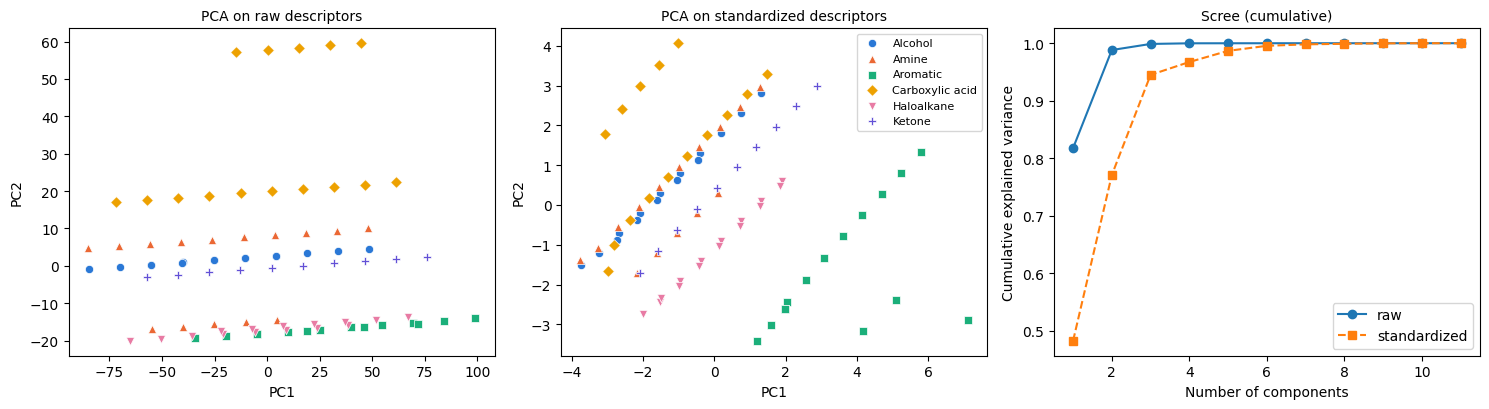

In [6]:
X_std = StandardScaler().fit_transform(X_raw)

pca_raw = PCA().fit(X_raw - X_raw.mean(axis=0))
pca_std = PCA().fit(X_std)

print("Explained variance ratio (raw):         ", np.round(pca_raw.explained_variance_ratio_[:4], 4))
print("Explained variance ratio (standardized):", np.round(pca_std.explained_variance_ratio_[:4], 4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
Y_raw = pca_raw.transform(X_raw - X_raw.mean(axis=0))[:, :2]
Y_pca = pca_std.transform(X_std)[:, :2]
plot_by_class(axes[0], Y_raw, "PCA on raw descriptors", "PC1", "PC2")
plot_by_class(axes[1], Y_pca, "PCA on standardized descriptors", "PC1", "PC2")

k = np.arange(1, len(feature_cols) + 1)
axes[2].plot(k, np.cumsum(pca_raw.explained_variance_ratio_), "o-", label="raw")
axes[2].plot(k, np.cumsum(pca_std.explained_variance_ratio_), "s--", label="standardized")
axes[2].set_xlabel("Number of components")
axes[2].set_ylabel("Cumulative explained variance")
axes[2].set_title("Scree (cumulative)", fontsize=10)
axes[2].legend()
axes[1].legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig("fig1_pca.png", dpi=150)
plt.show()

### PCA loadings (standardized)

In [7]:
loadings = pd.DataFrame(pca_std.components_[:2].T, index=feature_cols, columns=["PC1", "PC2"])
print(loadings.round(3).sort_values("PC1", key=abs, ascending=False))

              PC1    PC2
LogP        0.404  0.116
MolMR       0.389  0.239
HeavyAtoms  0.355  0.297
MolWt       0.348  0.295
Rings       0.319 -0.246
AromRings   0.319 -0.246
HBA        -0.252  0.360
HBD        -0.231  0.320
TPSA       -0.211  0.360
FracCSP3   -0.195  0.205
RotBonds    0.187  0.480


### YOUR TURN (B1)
1. Why does raw-data PCA give a very high PC1 explained variance? Which descriptor dominates?
2. Using the loadings, give a chemical name to PC1 and PC2 of the standardized PCA.
3. How many components are needed to reach 90% of the variance (standardized)?

1. PC1 mainly represents molecular size/lipophilicity (dominated by LogP, MolMR, HeavyAtoms, MolWt, rings). PC2 primarily reflects polarity/flexibility versus aromaticity (RotB, HBA, HBD, TPSA vs. Rings, AromRings).

2. In raw-data PCA, Molecular Weight (MolWt) dominates PC1 due to its large numerical scale, causing the PCA to be heavily influenced by molecular size.

3. Three principal components are needed to achieve over 90% cumulative explained variance (approx. 94.5% from PC1: 48.3%, PC2: 28.8%, PC3: 17.4%).

In [8]:
n90 = int(np.searchsorted(np.cumsum(pca_std.explained_variance_ratio_), 0.90) + 1)
print("Components needed for 90% variance (standardized):", n90)

Components needed for 90% variance (standardized): 3


## 4. t-SNE: effect of perplexity and random seed

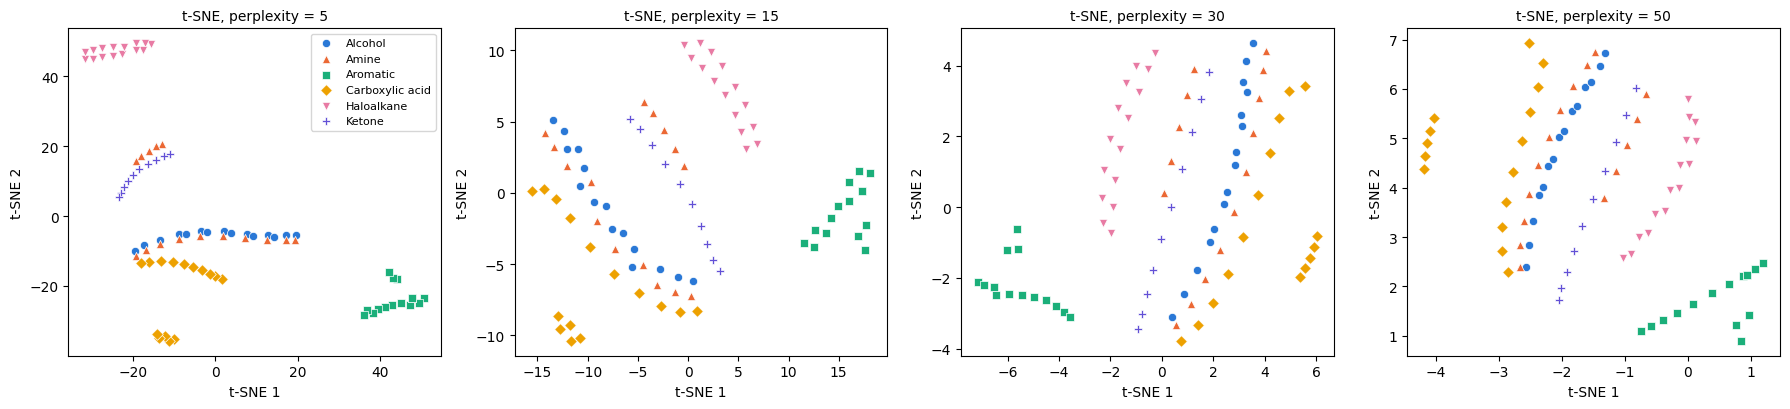

In [9]:
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, len(perplexities), figsize=(18, 4.2))
tsne_results = {}
for ax, p in zip(axes, perplexities):
    Y = TSNE(n_components=2, perplexity=p, init="pca", learning_rate="auto",
             random_state=SEED).fit_transform(X_std)
    tsne_results[p] = Y
    plot_by_class(ax, Y, f"t-SNE, perplexity = {p}", "t-SNE 1", "t-SNE 2")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig2_tsne_perplexity.png", dpi=150)
plt.show()

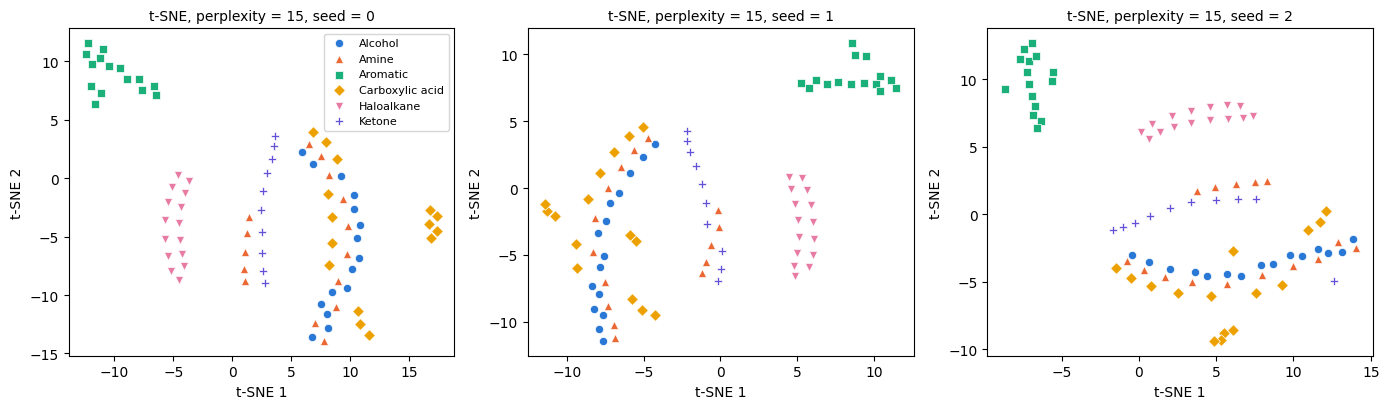

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, seed in zip(axes, [0, 1, 2]):
    Y = TSNE(n_components=2, perplexity=15, init="random", learning_rate="auto",
             random_state=seed).fit_transform(X_std)
    plot_by_class(ax, Y, f"t-SNE, perplexity = 15, seed = {seed}", "t-SNE 1", "t-SNE 2")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig3_tsne_seeds.png", dpi=150)
plt.show()

### YOUR TURN (B2)
1. How does the map change as perplexity increases from 5 to 50?
2. Which features stay the same across seeds, and which change?
3. Why is perplexity = 100 not allowed for this dataset?

1. As perplexity increases from 5 to 50, t-SNE transitions from focusing on very local relationships (smaller, fragmented groups) to considering larger neighborhoods, resulting in clearer class separation and a more global arrangement. Exact positions and orientations of clusters should not be over interpreted.

2. Local neighborhoods, grouping of similar chemical classes, and ordering within homologous series remain stable. However, exact position, orientation, rotation, reflection, and spacing of clusters can change due to t-SNE's stochastic nature and different initializations.

3. Perplexity must be less than the number of samples. With 85 molecules in the dataset, a perplexity of 100 is invalid.

## 5. UMAP: effect of n_neighbors and min_dist

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


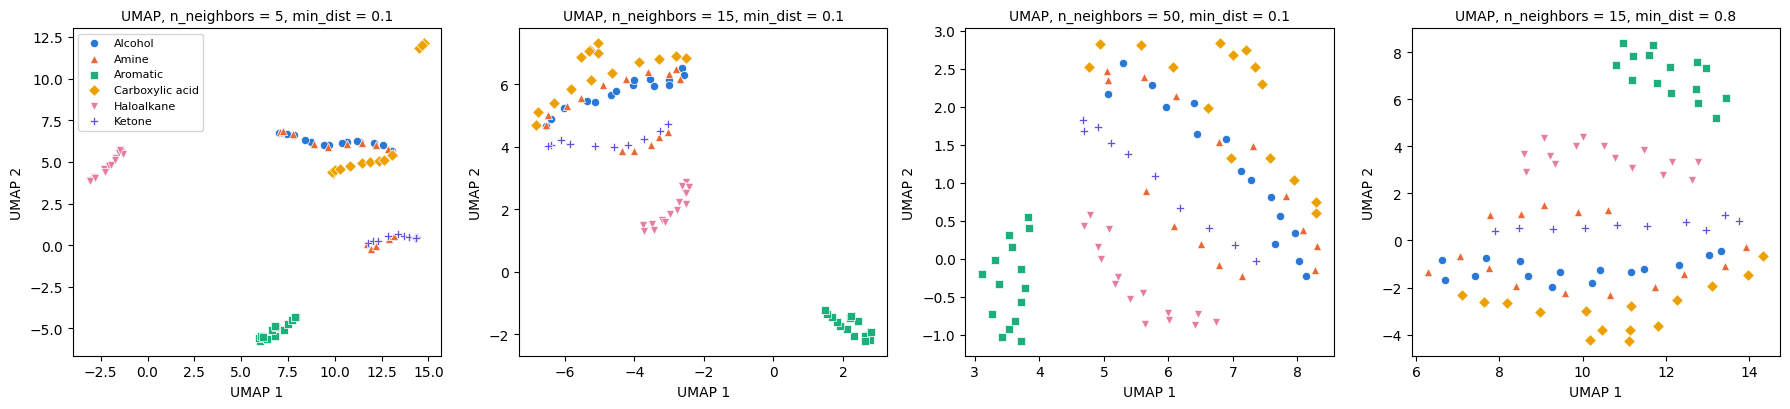

In [11]:
umap_results = {}
if HAVE_UMAP:
    settings = [(5, 0.1), (15, 0.1), (50, 0.1), (15, 0.8)]
    fig, axes = plt.subplots(1, len(settings), figsize=(18, 4.2))
    for ax, (nn, md) in zip(axes, settings):
        Y = umap.UMAP(n_neighbors=nn, min_dist=md, random_state=SEED).fit_transform(X_std)
        umap_results[(nn, md)] = Y
        plot_by_class(ax, Y, f"UMAP, n_neighbors = {nn}, min_dist = {md}", "UMAP 1", "UMAP 2")
    axes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("fig4_umap.png", dpi=150)
    plt.show()

### YOUR TURN (B3)
1. Compare n_neighbors = 5 and 50. Which shows more local detail, which more global layout?
2. What does increasing min_dist from 0.1 to 0.8 do to the clusters?



1. Increasing n_neighbors from 5 to 50 shifts UMAP's emphasis from local structure (detailed clusters) to global structure (smoother, more connected arrangements).

2. A small min_dist (e.g., 0.1) creates compact, well-defined clusters, while a large min_dist (e.g., 0.8) leads to more spread-out and diffuse clusters with greater spacing between points.

## 6. Colour by a continuous property

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
plot_by_value(axes[0], Y_pca, data["LogP"], "PCA coloured by LogP", "LogP")
plot_by_value(axes[1], tsne_results[30], data["LogP"], "t-SNE coloured by LogP", "LogP")
if HAVE_UMAP:
    plot_by_value(axes[2], umap_results[(15, 0.1)], data["LogP"], "UMAP coloured by LogP", "LogP")
else:
    axes[2].axis("off")
plt.tight_layout()
plt.savefig("fig5_logp.png", dpi=150)
plt.show()

### YOUR TURN (B4)
Inside each class cluster, is there a smooth LogP gradient? What structural change
(hint: chain length) produces it?

1. There is a smooth LogP gradient within most chemical classes, primarily due to increasing carbon chain length. Longer chains add more non-polar carbon atoms, increasing hydrophobic character and thus LogP values. This explains the gradual color gradient in the plots.

## 7. Quantitative comparison: trustworthiness
Trustworthiness (0 to 1) measures how well each point's nearest neighbours in the map
were also neighbours in the original space. 1 means perfect local preservation.

In [ ]:
emb = {"PCA (2 PCs)": Y_pca, "t-SNE (perp 30)": tsne_results[30]}
if HAVE_UMAP:
    emb["UMAP (nn 15)"] = umap_results[(15, 0.1)]

for k_nn in [5, 15]:
    for name, Y in emb.items():
        t = trustworthiness(X_std, Y, n_neighbors=k_nn)
        print(f"k = {k_nn:2d}  {name:18s} trustworthiness = {t:.3f}")

### YOUR TURN (B5)
1. Which method preserves local neighbourhoods best? Is that what you expected?
2. Trustworthiness says nothing about distances between clusters. Propose a check
   for global structure (hint: correlate pairwise distances in the original and 2D spaces).


1. Trustworthiness measures how well local neighborhoods are preserved. For k=5, t-SNE shows the highest trustworthiness (approx. 0.996), preserving very local neighborhoods best. For k=15, PCA performs slightly better (approx. 0.981). Generally, t-SNE excels at preserving local neighborhoods.

2.  Global structure can be assessed by comparing pairwise distances between molecules in the original high-dimensional space and the 2D embedding (e.g., using Spearman correlation). High correlation indicates good preservation of global structure, while low correlation suggests distortion. This metric complements trustworthiness by evaluating broader relationships.